<a href="https://colab.research.google.com/github/moratodpg/risk_reliability/blob/main/demos/r01_extremes_tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Guided Tutorial. Extremes

This guided tutorial introduces two standard approaches for estimating rare wind speeds. 
- The block maximum method models maxima over fixed time blocks. 
- The peak-over-threshold method models independent exceedances above a high threshold.

Session Plan

1. Use Colab and Python for data analysis.
2. Inspect a wind-speed record and define extremes.
3. Apply the block maximum method.
4. Apply the peak-over-threshold method.
5. Compare estimates and discuss modeling assumptions.

In [ ]:
#import drive and os libraries
from google.colab import drive
import os

#mount google drive
drive.mount('/content/drive', force_remount=True)

## Colab and Python Basics

Google Colab runs notebooks in a browser. A notebook is made of text cells and code cells. Run a selected cell with Shift and Enter. If a dataset is needed, upload it from the file panel or read it from a URL. In Python, packages are loaded with `import`, tabular data are often stored in pandas DataFrames, and plots are commonly made with Matplotlib.

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['figure.figsize'] = (8, 4.5)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

## Create an Example Wind-Speed Record

For the tutorial, we use a synthetic record of daily maximum 10-minute mean wind speed. The background process is kept below the POT threshold, while storm events are generated separately. This is deliberate: it lets us know the tail-generating mechanism and check whether the extreme-value methods behave sensibly.


In [2]:
rng = np.random.default_rng(7)

# Twenty years gives a modest but usable sample for both annual maxima and POT.
dates = pd.date_range('2002-01-01', '2021-12-31', freq='D')
day = dates.dayofyear.to_numpy()
seasonal = 2.3 * (1 + np.cos(2 * np.pi * (day - 25) / 365.25)) / 2
background = 6.5 + seasonal + rng.weibull(2.0, len(dates)) * 5.7
noise = rng.normal(0, 0.5, len(dates))

# Keep ordinary days below the threshold used later for POT.
threshold_true = 25.0
wind_speed = np.clip(background + noise, 2.5, threshold_true - 0.5)

tutorial = pd.DataFrame({
    'date': dates,
    'year': dates.year,
    'daily_max_10min_wind_ms': wind_speed,
})

# Synthetic storm process.
# Independent storm peaks arrive at about 3 events/year.
# Their excesses above 25 m/s follow a GPD with known parameters.
lambda_true = 3.0
xi_true = 0.10
sigma_true = 2.0

for year in sorted(tutorial['year'].unique()):
    n_storms = rng.poisson(lambda_true)
    candidate_dates = tutorial.loc[tutorial['year'] == year, 'date'].iloc[3:-3].to_numpy()

    # Keep generated storm centers well separated so different storms are distinct.
    storm_centers = []
    attempts = 0
    while len(storm_centers) < n_storms and attempts < 500:
        date = pd.Timestamp(rng.choice(candidate_dates))
        if all(abs((date - old_date).days) > 7 for old_date in storm_centers):
            storm_centers.append(date)
        attempts += 1

    for date in storm_centers:
        excess = stats.genpareto.rvs(c=xi_true, loc=0, scale=sigma_true, random_state=rng)
        peak = threshold_true + excess

        # Represent one storm by a short three-day cluster.
        cluster_values = [
            threshold_true + max(0.05, 0.35 * excess),
            peak,
            threshold_true + max(0.05, 0.55 * excess),
        ]
        for offset, value in zip([-1, 0, 1], cluster_values):
            mask = tutorial['date'] == date + pd.Timedelta(days=offset)
            tutorial.loc[mask, 'daily_max_10min_wind_ms'] = value

tutorial['daily_max_10min_wind_ms'] = tutorial['daily_max_10min_wind_ms'].round(2)
tutorial.head()


,date,year,daily_max_10min_wind_ms
0,2002-01-01,2002,13.39
1,2002-01-02,2002,14.32
2,2002-01-03,2002,12.95
3,2002-01-04,2002,13.82
4,2002-01-05,2002,10.88


## What Counts as an Extreme?

Extreme-value analysis studies the tail of a distribution rather than the average day. For wind engineering, the main question is usually a return level. A return level $z_T$ is exceeded with probability $1/T$ in a single year.

In [3]:
summary = tutorial['daily_max_10min_wind_ms'].describe(percentiles=[0.5, 0.9, 0.95, 0.99])
summary.to_frame('wind_speed_ms')

,wind_speed_ms
count,7305.000000
mean,13.053073
std,3.510492
min,5.690000
50%,12.510000
90%,17.076000
95%,18.858000
99%,26.079600
max,36.620000


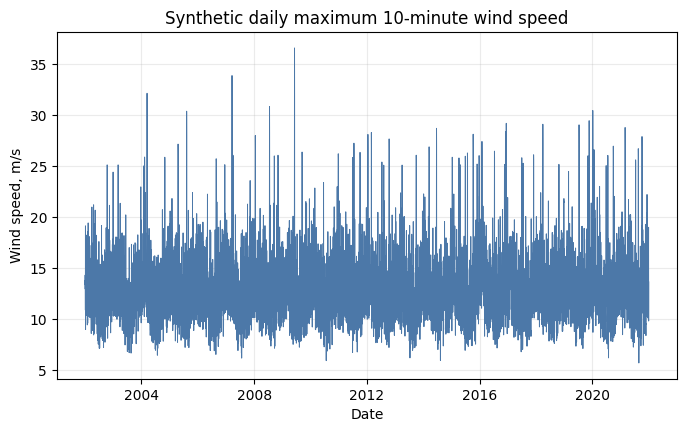

In [4]:
fig, ax = plt.subplots()
ax.plot(tutorial['date'], tutorial['daily_max_10min_wind_ms'], lw=0.7, color='#4c78a8')
ax.set_title('Synthetic daily maximum 10-minute wind speed')
ax.set_xlabel('Date')
ax.set_ylabel('Wind speed, m/s')
plt.show()

## Block Maximum Method

The block maximum method divides the record into equal time blocks and retains the largest observation in each block. Here the blocks are calendar years.

Extreme-value theory motivates the **generalized extreme-value (GEV)** family for block maxima. For simplicity in this tutorial, we use its Gumbel special case, corresponding to GEV shape parameter $\xi=0$.


In [5]:
annual_maxima = (
    tutorial.loc[tutorial.groupby('year')['daily_max_10min_wind_ms'].idxmax(), ['year', 'date', 'daily_max_10min_wind_ms']]
    .rename(columns={'daily_max_10min_wind_ms': 'annual_maximum_ms'})
    .reset_index(drop=True)
)
annual_maxima

,year,date,annual_maximum_ms
0,2002,2002-10-14,25.14
1,2003,2003-03-05,25.14
2,2004,2004-03-14,32.17
3,2005,2005-08-09,30.41
4,2006,2006-08-27,25.74
5,2007,2007-03-20,33.91
6,2008,2008-07-18,30.86
7,2009,2009-06-07,36.62
8,2010,2010-12-26,26.23
9,2011,2011-07-17,27.27


For a Gumbel distribution,

$$F(x)=\exp\{-\exp[-(x-u)/\beta]\}.$$

The method-of-moments estimates use the sample mean $\bar{x}$ and the sample second central moment of the annual maxima,

$$m_2=\frac{1}{n}\sum_{i=1}^n (x_i-\bar{x})^2.$$

Writing $s_0=\sqrt{m_2}$,

$$\beta=\frac{s_0\sqrt{6}}{\pi}, \qquad u=\bar{x}-\gamma\beta,$$

where $\gamma \approx 0.5772$ is the Euler-Mascheroni constant.

The use of $1/n$ here is intentional because this is a method-of-moments calculation, not the unbiased sample-variance estimator.


In [6]:
xbar = annual_maxima['annual_maximum_ms'].mean()
s0 = annual_maxima['annual_maximum_ms'].std(ddof=0)
gamma = 0.5772156649015329
beta = s0 * math.sqrt(6) / math.pi
u = xbar - gamma * beta

pd.Series({
    'mean_of_annual_maxima_ms': xbar,
    'moment_sd_of_annual_maxima_ms': s0,
    'gumbel_location_u_ms': u,
    'gumbel_scale_beta_ms': beta,
}).to_frame('value')


,value
mean_of_annual_maxima_ms,28.901500
moment_sd_of_annual_maxima_ms,2.907341
gumbel_location_u_ms,27.593042
gumbel_scale_beta_ms,2.266845


The return-period probability is $p_T=1-1/T$. The inverse Gumbel distribution gives

$$z_T=u-\beta\ln[-\ln(p_T)].$$

In [7]:
return_periods = np.array([10, 20, 50, 100])
block_rows = []
for T in return_periods:
    p_T = 1 - 1 / T
    z_T = u - beta * math.log(-math.log(p_T))
    block_rows.append({'return_period_years': T, 'annual_non_exceedance_probability': p_T, 'block_gumbel_return_level_ms': z_T})
block_results = pd.DataFrame(block_rows)
block_results.round(2)

,return_period_years,annual_non_exceedance_probability,block_gumbel_return_level_ms
0,10,0.90,32.69
1,20,0.95,34.33
2,50,0.98,36.44
3,100,0.99,38.02


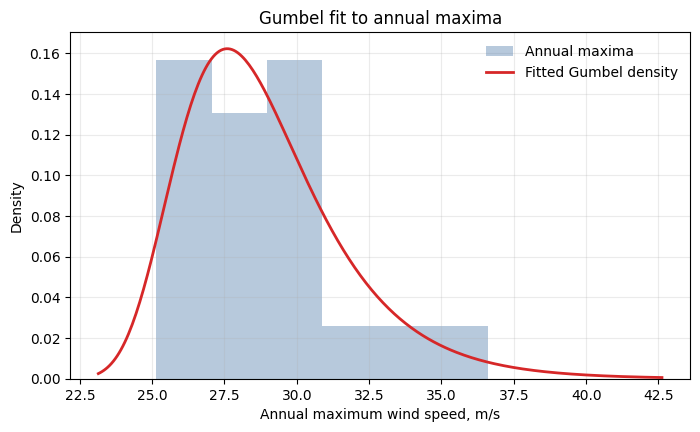

In [8]:
x_grid = np.linspace(annual_maxima['annual_maximum_ms'].min() - 2, annual_maxima['annual_maximum_ms'].max() + 6, 300)
fig, ax = plt.subplots()
ax.hist(annual_maxima['annual_maximum_ms'], bins=6, density=True, alpha=0.4, color='#4c78a8', label='Annual maxima')
ax.plot(x_grid, stats.gumbel_r.pdf(x_grid, loc=u, scale=beta), color='#d62728', lw=2, label='Fitted Gumbel density')
ax.set_title('Gumbel fit to annual maxima')
ax.set_xlabel('Annual maximum wind speed, m/s')
ax.set_ylabel('Density')
ax.legend(frameon=False)
plt.show()

## Peak-Over-Threshold Method

The peak-over-threshold (POT) method keeps all sufficiently high **independent events**. It can use more tail information than annual maxima, but it requires a threshold and, for dependent time series, a declustering rule.


In [9]:
threshold = 25.0
storm_gap_days = 3

# First identify all days above the threshold.
exceedance_days = tutorial[tutorial['daily_max_10min_wind_ms'] > threshold].copy()

# Runs declustering: exceedance days separated by more than 3 days start a new storm.
gap = exceedance_days['date'].diff().dt.days.fillna(storm_gap_days + 1)
exceedance_days['cluster'] = (gap > storm_gap_days).cumsum()

# Retain only the highest value from each storm cluster.
pot_events = (
    exceedance_days.loc[
        exceedance_days.groupby('cluster')['daily_max_10min_wind_ms'].idxmax(),
        ['cluster', 'date', 'daily_max_10min_wind_ms']
    ]
    .rename(columns={'daily_max_10min_wind_ms': 'storm_peak_ms'})
    .reset_index(drop=True)
)
pot_events['excess_ms'] = pot_events['storm_peak_ms'] - threshold

print(f'Days above threshold: {len(exceedance_days)}')
print(f'Independent storm peaks after declustering: {len(pot_events)}')
pot_events.head(10)


Days above threshold: 183
Independent storm peaks after declustering: 61


,cluster,date,storm_peak_ms,excess_ms
0,1,2002-10-14,25.14,0.14
1,2,2003-03-05,25.14,0.14
2,3,2004-02-01,25.05,0.05
3,4,2004-02-11,25.91,0.91
4,5,2004-03-14,32.17,7.17
5,6,2004-10-30,25.89,0.89
6,7,2005-04-20,27.18,2.18
7,8,2005-08-09,30.41,5.41
8,9,2006-08-27,25.74,0.74
9,10,2006-12-16,25.16,0.16


For excesses $Y=X-u_0$ above a sufficiently high threshold $u_0$, extreme-value theory motivates the **generalized Pareto distribution (GPD)**,

$$P(Y>y)=\left(1+\xi y/\sigma\right)^{-1/\xi},$$

on the support where $1+\xi y/\sigma>0$.

The shape parameter $\xi$ controls tail behavior. Positive values indicate a heavy tail, negative values imply a finite upper endpoint, and the limit $\xi\to0$ gives an **exponential distribution** for the excesses.

This distinction is important: a **Gumbel distribution is used for block maxima**, not directly for POT excesses. The $\xi=0$ POT case is exponential, not Gumbel.


In [10]:
excesses = pot_events['excess_ms'].to_numpy()
xi, loc, sigma = stats.genpareto.fit(excesses, floc=0)
lambda_rate = len(pot_events) / tutorial['year'].nunique()

pd.Series({
    'threshold_u0_ms': threshold,
    'number_of_independent_exceedances': len(pot_events),
    'exceedance_rate_lambda_per_year': lambda_rate,
    'gpd_shape_xi': xi,
    'gpd_scale_sigma_ms': sigma,
    'true_shape_xi_used_in_simulation': xi_true,
    'true_scale_sigma_ms_used_in_simulation': sigma_true,
    'true_storm_rate_per_year_used_in_simulation': lambda_true,
}).to_frame('value')


,value
threshold_u0_ms,25.000000
number_of_independent_exceedances,61.000000
exceedance_rate_lambda_per_year,3.050000
gpd_shape_xi,0.055061
gpd_scale_sigma_ms,2.012457
true_shape_xi_used_in_simulation,0.100000
true_scale_sigma_ms_used_in_simulation,2.000000
true_storm_rate_per_year_used_in_simulation,3.000000


In [11]:
def pot_return_level(T, threshold, sigma, xi, lambda_rate):
    tail_probability = -math.log(1 - 1 / T) / lambda_rate
    if abs(xi) < 1e-8:
        return threshold + sigma * math.log(1 / tail_probability)
    return threshold + (sigma / xi) * (tail_probability ** (-xi) - 1)

pot_rows = []
for T in return_periods:
    pot_rows.append({'return_period_years': T, 'pot_gpd_return_level_ms': pot_return_level(T, threshold, sigma, xi, lambda_rate)})
pot_results = pd.DataFrame(pot_rows)
pot_results.round(2)

,return_period_years,pot_gpd_return_level_ms
0,10,32.44
1,20,34.22
2,50,36.63
3,100,38.52


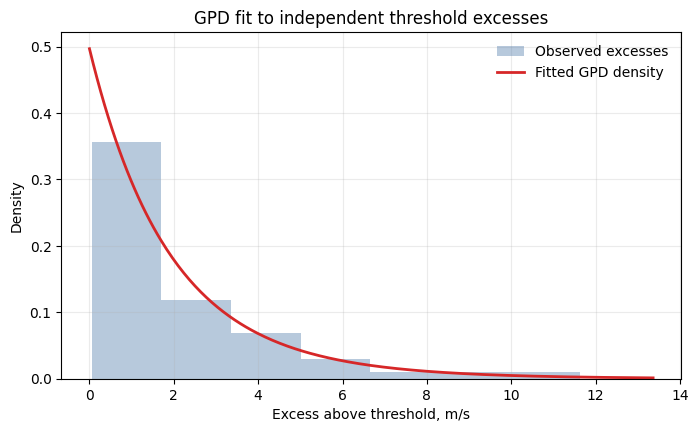

In [12]:
fig, ax = plt.subplots()
ax.hist(excesses, bins=7, density=True, alpha=0.4, color='#4c78a8', label='Observed excesses')

# Respect the fitted GPD support when drawing the density.
if xi < 0:
    fitted_endpoint = -sigma / xi
    y_max = min(excesses.max() * 1.15, fitted_endpoint * 0.995)
else:
    y_max = excesses.max() * 1.15

y_grid = np.linspace(0, y_max, 300)
ax.plot(
    y_grid,
    stats.genpareto.pdf(y_grid, c=xi, loc=0, scale=sigma),
    color='#d62728',
    lw=2,
    label='Fitted GPD density',
)
ax.set_title('GPD fit to independent threshold excesses')
ax.set_xlabel('Excess above threshold, m/s')
ax.set_ylabel('Density')
ax.legend(frameon=False)
plt.show()


A density histogram can be noisy for tail samples. A complementary diagnostic compares the empirical distribution of the excesses with the fitted GPD CDF. Points close to the diagonal indicate reasonable agreement, although formal uncertainty is still substantial for small samples.


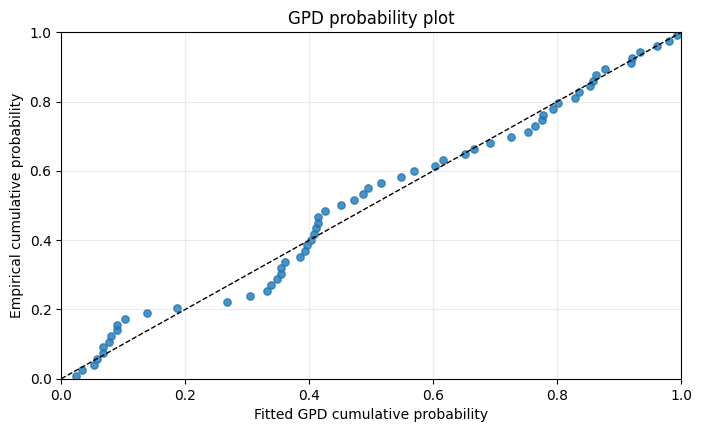

In [13]:
sorted_excesses = np.sort(excesses)
empirical_p = (np.arange(1, len(sorted_excesses) + 1) - 0.5) / len(sorted_excesses)
fitted_p = stats.genpareto.cdf(sorted_excesses, c=xi, loc=0, scale=sigma)

fig, ax = plt.subplots()
ax.scatter(fitted_p, empirical_p, s=28, alpha=0.8)
ax.plot([0, 1], [0, 1], color='black', lw=1, ls='--')
ax.set_title('GPD probability plot')
ax.set_xlabel('Fitted GPD cumulative probability')
ax.set_ylabel('Empirical cumulative probability')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
plt.show()


## Compare the Methods

Both methods estimate rare wind speeds, but they summarize the data differently. A disagreement is not a coding error by itself. It may reflect the block-distribution assumption, threshold choice, tail shape, sample size, dependence between events, or statistical estimation uncertainty.

In this synthetic example the storm excesses were generated from a GPD, so the POT model is correctly specified apart from finite-sample estimation error. The Gumbel block-maxima model is used as a pedagogical simplification of the broader GEV family.


In [14]:
comparison = block_results.merge(pot_results, on='return_period_years')
comparison['pot_minus_block_ms'] = comparison['pot_gpd_return_level_ms'] - comparison['block_gumbel_return_level_ms']
comparison.round(2)

,return_period_years,annual_non_exceedance_probability,block_gumbel_return_level_ms,pot_gpd_return_level_ms,pot_minus_block_ms
0,10,0.90,32.69,32.44,-0.25
1,20,0.95,34.33,34.22,-0.11
2,50,0.98,36.44,36.63,0.19
3,100,0.99,38.02,38.52,0.50


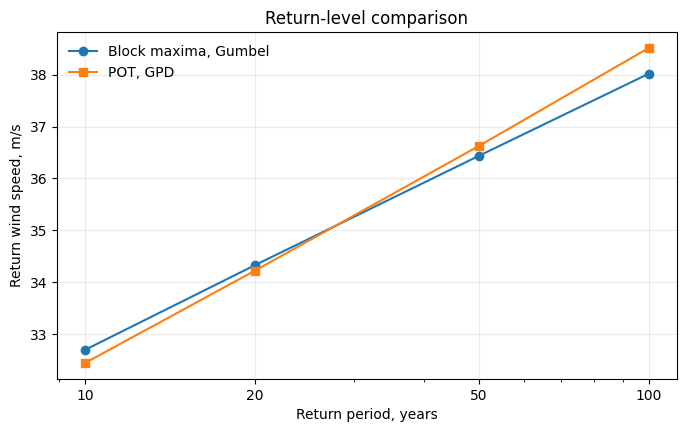

In [15]:
fig, ax = plt.subplots()
ax.plot(comparison['return_period_years'], comparison['block_gumbel_return_level_ms'], marker='o', label='Block maxima, Gumbel')
ax.plot(comparison['return_period_years'], comparison['pot_gpd_return_level_ms'], marker='s', label='POT, GPD')
ax.set_xscale('log')
ax.set_xticks(return_periods)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())
ax.set_title('Return-level comparison')
ax.set_xlabel('Return period, years')
ax.set_ylabel('Return wind speed, m/s')
ax.legend(frameon=False)
plt.show()

## Reflection

1. Which observations influence the block maximum fit most strongly?
2. What changes when the POT threshold is moved upward or downward?
3. Why does declustering matter for storm-driven wind speeds?
4. Why is the GPD natural for POT while the Gumbel is natural for block maxima?
5. The synthetic truth is $\xi=0.10$ and $\sigma=2.0$ m/s. How close are the fitted parameters, and why should we not expect them to match exactly?
6. Which return-level result would you report if the two methods differ, and what uncertainty statement would you include?
